In [1]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit

csv_path=r"C:\Users\Administrator\Desktop\Chess\data\input\moreE.csv"
df=pd.read_csv(csv_path)

In [2]:
df=df.drop(columns=['row_idx', 'Complexity P', 'Complexity S','White Complexity Sum', 'Black Complexity Sum','Stage Analysis'])
df.columns

Index(['UID', 'White', 'Black', 'White CP Loss', 'White Accuracy',
       'Black CP Loss', 'Black Accuracy', 'Evaluation', 'ComplexityE',
       'Judgments', 'White Blunders', 'White Mistakes', 'White Inaccuracies',
       'Black Blunders', 'Black Mistakes', 'Black Inaccuracies',
       'Complexity E1', 'Complexity E2', 'Complexity E3', 'Complexity E4',
       'Complexity E5'],
      dtype='object')

In [3]:
df.head()

,UID,White,Black,White CP Loss,White Accuracy,Black CP Loss,Black Accuracy,Evaluation,ComplexityE,Judgments,...,White Mistakes,White Inaccuracies,Black Blunders,Black Mistakes,Black Inaccuracies,Complexity E1,Complexity E2,Complexity E3,Complexity E4,Complexity E5
0,1,Petra Kejzar,Daniel Barria,38.9,90.9,2.7,99.7,"0.22,0.26,0.28,0.31,0.31,0.36,0.33,0.36,0.35,0...","22,26,28,31,31,36,33,36,35,35,35,37,29,32,32,3...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,Bl...",...,0,0,0,0,0,"33,22,26,28,31,31,36,33,36,35,35,35,37,29,32,3...","24,24,22,29,30,31,24,35,14,40,19,36,29,33,22,4...","22,27,11,32,22,35,21,46,9,57,9,37,25,50,18,53,...","18,45,7,52,8,36,17,46,6,63,-15,38,24,55,18,59,...","16,49,6,60,6,38,16,48,3,72,-623,55,13,60,11,59..."
1,2,Nataliya Buksa,Jorge Carlos Antonio,21.2,94.2,97.8,83.4,"0.24,0.27,-0.10,0.19,0.02,0.05,0.00,0.02,0.01,...","24,27,-10,19,2,5,0,2,1,1,-4,-9,5,-6,-18,224,20...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,Blunder,-,-,Mist...",...,1,0,4,0,0,"25,24,27,-10,19,2,5,0,2,1,1,-4,-9,5,-6,-18,224...","21,28,27,-3,4,16,1,19,0,1,-1,3,-15,45,-18,43,6...","19,35,10,6,3,22,1,21,-1,16,-2,4,-16,52,-33,47,...","17,43,10,21,0,24,-1,23,-1,18,-8,11,-18,154,-41...","15,51,3,22,-1,28,-7,26,-2,19,-9,17,-26,169,-54..."
2,3,Hubert Zieba,Nikolaos Skiadopoulos,31.7,91.4,62.6,88.2,"0.23,0.20,0.22,0.64,0.66,0.58,0.54,0.62,0.57,0...","23,20,22,64,66,58,54,62,57,55,56,71,65,64,61,7...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,...",...,1,0,2,0,0,"31,23,20,22,64,66,58,54,62,57,55,56,71,65,64,6...","24,25,20,26,20,94,36,84,60,62,34,73,-2,355,40,...","22,37,13,29,17,95,35,88,28,63,16,91,-36,357,9,...","14,40,10,50,11,96,21,139,22,73,-8,96,-67,369,7...","11,61,8,52,-6,100,21,143,4,104,-18,124,-70,388..."
3,4,Karina Ambartsumova,Nino Maisuradze,28.8,91.6,87.1,82.4,"0.20,0.20,0.05,0.50,0.42,0.43,0.31,0.25,0.30,0...","20,20,5,50,42,43,31,25,30,75,72,78,26,17,10,44...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,Mistake,-,-,...",...,1,0,1,2,0,"23,20,20,5,50,42,43,31,25,30,75,72,78,26,17,10...","22,21,11,6,24,46,33,98,15,31,70,121,65,83,14,1...","19,24,9,11,-9,50,29,107,14,33,67,140,49,305,13...","11,30,6,13,-11,52,26,119,14,33,55,144,49,326,8...","10,32,1,20,-20,56,21,122,9,34,54,149,43,328,2,..."
4,5,Alexander Donchenko,Andriy Diachek,26.8,91.6,49.5,86.4,"0.18,0.19,0.21,0.27,0.25,0.32,0.16,0.15,0.20,0...","18,19,21,27,25,32,16,15,20,17,24,30,24,25,6,27...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,Inaccuracy,-,-...",...,1,2,3,0,1,"32,18,19,21,27,25,32,16,15,20,17,24,30,24,25,6...","25,22,18,25,25,25,22,18,15,119,-57,42,8,32,17,...","18,47,17,34,25,35,6,18,5,174,-228,44,-41,34,3,...","11,48,11,47,9,35,-651,19,-19,409,,58,-61,40,-2...","4,49,9,53,7,36,,22,-52,476,,64,-114,48,-8,61,-..."


In [4]:
MISSING = '__MISSING__'
def split_with_missing_marker(x, marker='__MISSING__'):
    if not isinstance(x, str):
        return x

    tokens = x.split(',')
    return [t if t.strip() != '' else marker for t in tokens]

def parse_chess_data(df):
    list_cols = [
        'Judgments',
        'ComplexityE', 'Complexity E1', 'Complexity E2',
        'Complexity E3', 'Complexity E4', 'Complexity E5'
    ]

    # 1️ 复杂度列：只 split + 标记缺失，不转 float
    for col in list_cols:
        if col != 'Judgments':
            df[col] = df[col].apply(
                lambda x: split_with_missing_marker(x, marker=MISSING)
                if isinstance(x, str) else x
            )

    # 2️ Judgments 单独处理（它不涉及 float）
    df['Judgments'] = df['Judgments'].apply(
        lambda x: x.split(',') if isinstance(x, str) else x
    )

    return df


df=parse_chess_data(df)
df.head()

,UID,White,Black,White CP Loss,White Accuracy,Black CP Loss,Black Accuracy,Evaluation,ComplexityE,Judgments,...,White Mistakes,White Inaccuracies,Black Blunders,Black Mistakes,Black Inaccuracies,Complexity E1,Complexity E2,Complexity E3,Complexity E4,Complexity E5
0,1,Petra Kejzar,Daniel Barria,38.9,90.9,2.7,99.7,"0.22,0.26,0.28,0.31,0.31,0.36,0.33,0.36,0.35,0...","[22, 26, 28, 31, 31, 36, 33, 36, 35, 35, 35, 3...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,0,0,0,0,0,"[33, 22, 26, 28, 31, 31, 36, 33, 36, 35, 35, 3...","[24, 24, 22, 29, 30, 31, 24, 35, 14, 40, 19, 3...","[22, 27, 11, 32, 22, 35, 21, 46, 9, 57, 9, 37,...","[18, 45, 7, 52, 8, 36, 17, 46, 6, 63, -15, 38,...","[16, 49, 6, 60, 6, 38, 16, 48, 3, 72, -623, 55..."
1,2,Nataliya Buksa,Jorge Carlos Antonio,21.2,94.2,97.8,83.4,"0.24,0.27,-0.10,0.19,0.02,0.05,0.00,0.02,0.01,...","[24, 27, -10, 19, 2, 5, 0, 2, 1, 1, -4, -9, 5,...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,1,0,4,0,0,"[25, 24, 27, -10, 19, 2, 5, 0, 2, 1, 1, -4, -9...","[21, 28, 27, -3, 4, 16, 1, 19, 0, 1, -1, 3, -1...","[19, 35, 10, 6, 3, 22, 1, 21, -1, 16, -2, 4, -...","[17, 43, 10, 21, 0, 24, -1, 23, -1, 18, -8, 11...","[15, 51, 3, 22, -1, 28, -7, 26, -2, 19, -9, 17..."
2,3,Hubert Zieba,Nikolaos Skiadopoulos,31.7,91.4,62.6,88.2,"0.23,0.20,0.22,0.64,0.66,0.58,0.54,0.62,0.57,0...","[23, 20, 22, 64, 66, 58, 54, 62, 57, 55, 56, 7...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,1,0,2,0,0,"[31, 23, 20, 22, 64, 66, 58, 54, 62, 57, 55, 5...","[24, 25, 20, 26, 20, 94, 36, 84, 60, 62, 34, 7...","[22, 37, 13, 29, 17, 95, 35, 88, 28, 63, 16, 9...","[14, 40, 10, 50, 11, 96, 21, 139, 22, 73, -8, ...","[11, 61, 8, 52, -6, 100, 21, 143, 4, 104, -18,..."
3,4,Karina Ambartsumova,Nino Maisuradze,28.8,91.6,87.1,82.4,"0.20,0.20,0.05,0.50,0.42,0.43,0.31,0.25,0.30,0...","[20, 20, 5, 50, 42, 43, 31, 25, 30, 75, 72, 78...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,1,0,1,2,0,"[23, 20, 20, 5, 50, 42, 43, 31, 25, 30, 75, 72...","[22, 21, 11, 6, 24, 46, 33, 98, 15, 31, 70, 12...","[19, 24, 9, 11, -9, 50, 29, 107, 14, 33, 67, 1...","[11, 30, 6, 13, -11, 52, 26, 119, 14, 33, 55, ...","[10, 32, 1, 20, -20, 56, 21, 122, 9, 34, 54, 1..."
4,5,Alexander Donchenko,Andriy Diachek,26.8,91.6,49.5,86.4,"0.18,0.19,0.21,0.27,0.25,0.32,0.16,0.15,0.20,0...","[18, 19, 21, 27, 25, 32, 16, 15, 20, 17, 24, 3...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,1,2,3,0,1,"[32, 18, 19, 21, 27, 25, 32, 16, 15, 20, 17, 2...","[25, 22, 18, 25, 25, 25, 22, 18, 15, 119, -57,...","[18, 47, 17, 34, 25, 35, 6, 18, 5, 174, -228, ...","[11, 48, 11, 47, 9, 35, -651, 19, -19, 409, __...","[4, 49, 9, 53, 7, 36, __MISSING__, 22, -52, 47..."


In [5]:
MISSING = '__MISSING__'

complexity_cols = [
    'ComplexityE', 'Complexity E1', 'Complexity E2',
    'Complexity E3', 'Complexity E4', 'Complexity E5'
]

total_missing = 0

for col in complexity_cols:
    total_missing += df[col].apply(
        lambda x: x.count(MISSING) if isinstance(x, list) else 0
    ).sum()

total_missing

np.int64(35447)

In [6]:
df.shape

(3716, 21)

In [7]:
missing_by_col = {}

for col in df.columns:
    missing_by_col[col] = df[col].apply(
        lambda x: sum(1 for i in x if i == '__MISSING__') if isinstance(x, list) else 0
    ).sum()

missing_by_col

{'UID': np.int64(0),
 'White': np.int64(0),
 'Black': np.int64(0),
 'White CP Loss': np.int64(0),
 'White Accuracy': np.int64(0),
 'Black CP Loss': np.int64(0),
 'Black Accuracy': np.int64(0),
 'Evaluation': np.int64(0),
 'ComplexityE': np.int64(0),
 'Judgments': np.int64(0),
 'White Blunders': np.int64(0),
 'White Mistakes': np.int64(0),
 'White Inaccuracies': np.int64(0),
 'Black Blunders': np.int64(0),
 'Black Mistakes': np.int64(0),
 'Black Inaccuracies': np.int64(0),
 'Complexity E1': np.int64(0),
 'Complexity E2': np.int64(2362),
 'Complexity E3': np.int64(6406),
 'Complexity E4': np.int64(11072),
 'Complexity E5': np.int64(15607)}

In [8]:
def explode_chess_data(row):
    game_id = row['UID']
    white = row['White']
    black = row['Black']
    Es=row['ComplexityE']
    E1s=row['Complexity E1']
    E2s=row['Complexity E2']
    E3s=row['Complexity E3']
    E4s=row['Complexity E4']
    E5s=row['Complexity E5']

    judgments = row['Judgments']
    if not isinstance(Es, list):
        Es = []
    if not isinstance(E1s, list):
        E1s = []
    if not isinstance(E2s, list):
        E2s = []   
    if not isinstance(E3s, list):
        E3s = [] 
    if not isinstance(E4s, list):
        E4s = []   
    if not isinstance(E5s, list):
        E5s = [] 
    if not isinstance(judgments, list):
        judgments = []

    length = len(judgments)
    exploded_data = []
    
    for i in range(length):
        # 偶数步是白方，奇数步是黑方 (0, 1, 2, 3...)
        is_white_move = (i % 2 == 0)
        player_name = white if is_white_move else black
        
        judgment_str = judgments[i]
        
        # 标记是否为失误
        is_error = 1 if judgment_str in ['Blunder', 'Mistake'] else 0
        is_blunder = 1 if judgment_str == 'Blunder' else 0
        
        exploded_data.append({
            'uid': game_id,
            'Move_Idx': i + 1,        # 人类习惯从第1步开始
            'Player': player_name,
            'Color': 'White' if is_white_move else 'Black',
            'E': Es[i],
            'E1':E1s[i],
            'E2':E2s[i],
            'E3':E3s[i],
            'E4':E4s[i],
            'E5':E5s[i],
            'Judgment_Raw': judgment_str,
            'Is_Error': is_error,     # 关键指标：所有失误
            'Is_Blunder': is_blunder  # 关键指标：大失误
        })
        
    return exploded_data
all_moves = []

for index, row in df.iterrows():
    moves = explode_chess_data(row)
    all_moves.extend(moves)

df_moves = pd.DataFrame(all_moves)
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder
0,1,1,Petra Kejzar,White,22,33,24,22,18,16,-,0,0
1,1,2,Daniel Barria,Black,26,22,24,27,45,49,-,0,0
2,1,3,Petra Kejzar,White,28,26,22,11,7,6,-,0,0
3,1,4,Daniel Barria,Black,31,28,29,32,52,60,-,0,0
4,1,5,Petra Kejzar,White,31,31,30,22,8,6,-,0,0


check about the missing

In [9]:
def is_missing(x):
    return (x is None) or (isinstance(x, str) and x == '__MISSING__') or pd.isna(x)
cols_to_show = [
    'uid', 'Move_Idx', 'Player', 'Color',
    'E1', 'E2', 'E3', 'E4', 'E5'
]

df_E2_missing = df_moves[df_moves['E5'].apply(is_missing)][cols_to_show]
#display(df_E2_missing.head(50))

In [10]:
df_moves[['E', 'E1', 'E2', 'E3', 'E4', 'E5']].map(type).value_counts()

E              E1             E2             E3             E4             E5           
<class 'str'>  <class 'str'>  <class 'str'>  <class 'str'>  <class 'str'>  <class 'str'>    323689
Name: count, dtype: int64

In [11]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder
0,1,1,Petra Kejzar,White,22,33,24,22,18,16,-,0,0
1,1,2,Daniel Barria,Black,26,22,24,27,45,49,-,0,0
2,1,3,Petra Kejzar,White,28,26,22,11,7,6,-,0,0
3,1,4,Daniel Barria,Black,31,28,29,32,52,60,-,0,0
4,1,5,Petra Kejzar,White,31,31,30,22,8,6,-,0,0


In [12]:
numeric_cols = ['E', 'E1']

for col in numeric_cols:
    df_moves[col] = pd.to_numeric(df_moves[col], errors='coerce')

In [13]:
#white E1-E   black E-E1
def safe_sub(a, b):
    try:
        a = float(a)
        b = float(b)
    except (TypeError, ValueError):
        return np.nan
    return a - b
df_moves['Δi'] = df_moves.apply(
    lambda row: safe_sub(row['E1'], row['E2']),
    axis=1
)
df_moves.head(20)
print(df_moves['Δi'].describe())

count    321327.000000
mean          2.682719
std         932.477225
min      -19990.000000
25%         -13.000000
50%           0.000000
75%          13.000000
max       19992.000000
Name: Δi, dtype: float64


# Δ 定义（Decision Margin，决策裕度）
设在某一步走法决策中，定义核心参数：
- $E_1$：最优走法的评估值
- $E_k$：第 $k$ 优走法的评估值，$k \in \{2,3,4,5\}$
- $w_k$：第 $k$ 优走法对应的权重，固定为：

$$
w_2 = 0.4,\quad w_3 = 0.3,\quad w_4 = 0.2,\quad w_5 = 0.1
$$

记**存在的备选走法集合**为：
$$
\mathcal{K} = \{\, k \in \{2,3,4,5\} \mid E_k \text{ is available} \,\}
$$

## 白方走法（White move）
$$
\Delta = \frac{\sum\limits_{k \in \mathcal{K}} w_k \cdot (E_1 - E_k)}{\sum\limits_{k \in \mathcal{K}} w_k}
$$

## 黑方走法（Black move）
$$
\Delta = \frac{\sum\limits_{k \in \mathcal{K}} w_k \cdot (E_k - E_1)}{\sum\limits_{k \in \mathcal{K}} w_k}
$$

## 特殊情况（Special case）
若 $\mathcal{K} = \varnothing$（仅存在最优走法 $E_1$，无任何备选走法），定义：
$$
\Delta = 0
$$

## 注意事项（Notes）
1. 仅使用**连续存在**的 $E_2, E_3, \dots$，一旦某一 $E_k$ 缺失，后续所有项均不再参与计算；
2. 实际计算中，对本次参与运算的权重进行**归一化**处理；
3. 白方/黑方仅影响 $\Delta$ 的**符号方向**，不改变其数值尺度。

In [14]:
def compute_delta(row):
    Ei_cols=['E2', 'E3', 'E4', 'E5']
    color = row['Color']
    weights={'E2':0.4, 'E3':0.3, 'E4':0.2, 'E5':0.1}
    total_weight = 0.0
    E1 = row['E1']
    if pd.isna(E1): return np.nan

    delta = 0.0
    used_any = False

    for col in Ei_cols:
        Ei = row[col]
        try:
            Ei = float(Ei)
        except (TypeError, ValueError):
            break
        
        if pd.isna(Ei):
            break
        w =weights[col]
        total_weight += w
        if color =='White':
            delta += w*(E1 - Ei)
        else:
            delta += w*(Ei - E1)
        used_any = True

    if not used_any:
        return 0.0
    
    return delta/total_weight


df_moves['Δ'] = df_moves.apply(compute_delta, axis=1)

In [15]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ
0,1,1,Petra Kejzar,White,22,33,24,22,18,16,-,0,0,9.0,11.6
1,1,2,Daniel Barria,Black,26,22,24,27,45,49,-,0,0,-2.0,9.6
2,1,3,Petra Kejzar,White,28,26,22,11,7,6,-,0,0,4.0,11.9
3,1,4,Daniel Barria,Black,31,28,29,32,52,60,-,0,0,-1.0,9.6
4,1,5,Petra Kejzar,White,31,31,30,22,8,6,-,0,0,1.0,10.2


In [16]:
elo_info=pd.read_csv(r"C:\Users\Administrator\Desktop\Chess\ELO\temp.csv",usecols=['uid','player', 'My_Elo'] )
elo_info=elo_info[['uid','player', 'My_Elo']].rename(columns={'My_Elo':'ELO'})
elo_info=elo_info.set_index(['uid', 'player'])['ELO']
df_moves = df_moves.merge(
    elo_info,
    left_on=['uid', 'Player'],   # df_moves 中的列
    right_on=['uid', 'player'],      # elo_info 中的列
    how='left'
)
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO
0,1,1,Petra Kejzar,White,22,33,24,22,18,16,-,0,0,9.0,11.6,2177
1,1,2,Daniel Barria,Black,26,22,24,27,45,49,-,0,0,-2.0,9.6,2637
2,1,3,Petra Kejzar,White,28,26,22,11,7,6,-,0,0,4.0,11.9,2177
3,1,4,Daniel Barria,Black,31,28,29,32,52,60,-,0,0,-1.0,9.6,2637
4,1,5,Petra Kejzar,White,31,31,30,22,8,6,-,0,0,1.0,10.2,2177


In [26]:
def elo_group(elo):
    if elo < 2400:
        return 'Low (<2400)'
    elif 2400<= elo < 2800:
        return 'Mid (2400-2799)'
    else:
        return 'Top (>=2800)'

df_moves['ELO_Group'] = df_moves['ELO'].apply(elo_group)
df_moves['ELO_Group'].value_counts(normalize=True)

ELO_Group
Mid (2400-2799)    0.561857
Low (<2400)        0.267062
Top (>=2800)       0.171081
Name: proportion, dtype: float64

In [27]:
force_moves_csv=r'C:\Users\Administrator\Desktop\Chess\data\input\forced_moves_per_game.csv'
force_moves_df=pd.read_csv(force_moves_csv)
def ensure_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, (int, float)):
        return [int(x)]
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            if isinstance(v, list):
                return v
            elif isinstance(v, (int, float)):
                return [int(v)]
            else:
                return []
        except:
            return []
    try:
        return list(x)
    except:
        return []

force_moves_df['Forced_Move_Idx_List'] = force_moves_df['Forced_Move_Idx_List'].apply(ensure_list)

forced_expanded = []

for idx, row in force_moves_df.iterrows():
    game_id = row['Game_ID']
    for move_idx in row['Forced_Move_Idx_List']:
        forced_expanded.append({'Game_ID': game_id, 'Move_Idx': move_idx, 'Is_Forced': 1})

df_forced_expanded = pd.DataFrame(forced_expanded, columns=['Game_ID', 'Move_Idx', 'Is_Forced'])

cols_to_drop = [col for col in df_moves.columns if 'Is_Forced' in col]
df_moves = df_moves.drop(columns=cols_to_drop)

df_moves = df_moves.merge(df_forced_expanded, left_on=['uid', 'Move_Idx'],   # df_moves 的列名
    right_on=['Game_ID', 'Move_Idx'],  # df_forced_expanded 的列名
    how='left')
df_moves['Is_Forced'] = df_moves['Is_Forced'].fillna(0).astype(int)
df_moves['Is_Forced'].value_counts()

Is_Forced
0    321327
1      2362
Name: count, dtype: int64

In [28]:
tolerance_cp= 10
df_moves['Is_Optimal'] = np.where(df_moves['Δi'] <= tolerance_cp, 1, 0)
#df_moves.head(50)

In [29]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,...,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Game_ID_x,Is_Optimal,Game_ID_y,Is_Forced
0,1,1,Petra Kejzar,White,22,33,24,22,18,16,...,0,0,9.0,11.6,2177,Low (<2400),NaN,1,NaN,0
1,1,2,Daniel Barria,Black,26,22,24,27,45,49,...,0,0,-2.0,9.6,2637,Mid (2400-2799),NaN,1,NaN,0
2,1,3,Petra Kejzar,White,28,26,22,11,7,6,...,0,0,4.0,11.9,2177,Low (<2400),NaN,1,NaN,0
3,1,4,Daniel Barria,Black,31,28,29,32,52,60,...,0,0,-1.0,9.6,2637,Mid (2400-2799),NaN,1,NaN,0
4,1,5,Petra Kejzar,White,31,31,30,22,8,6,...,0,0,1.0,10.2,2177,Low (<2400),NaN,1,NaN,0


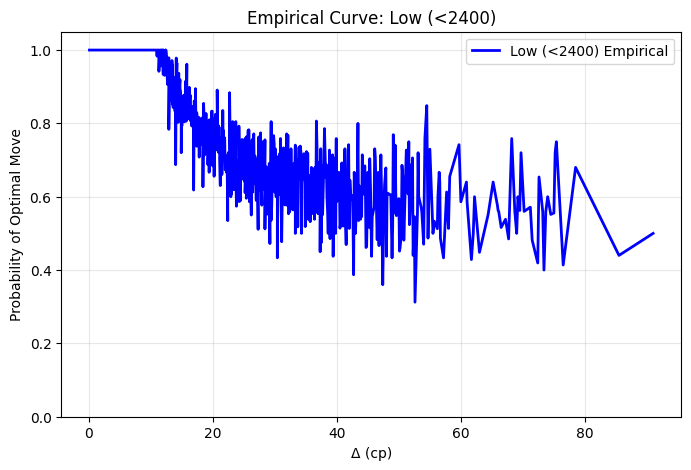

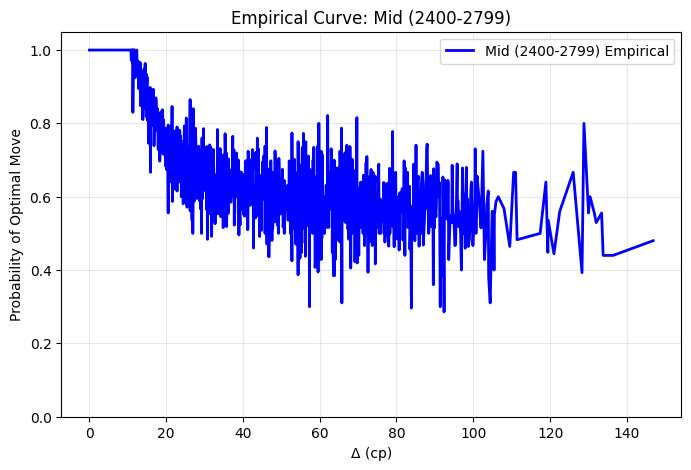

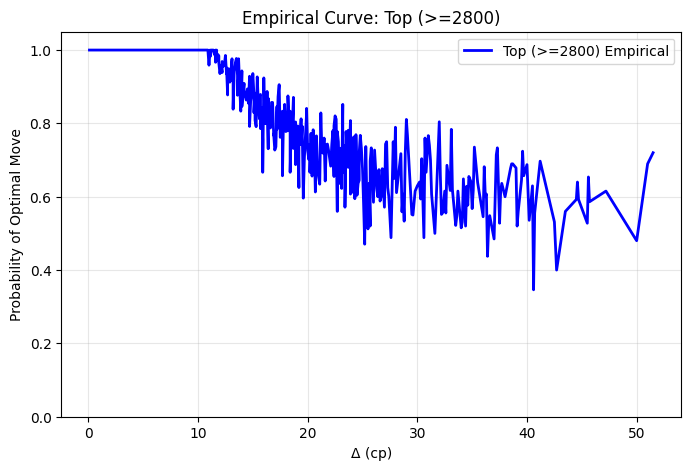

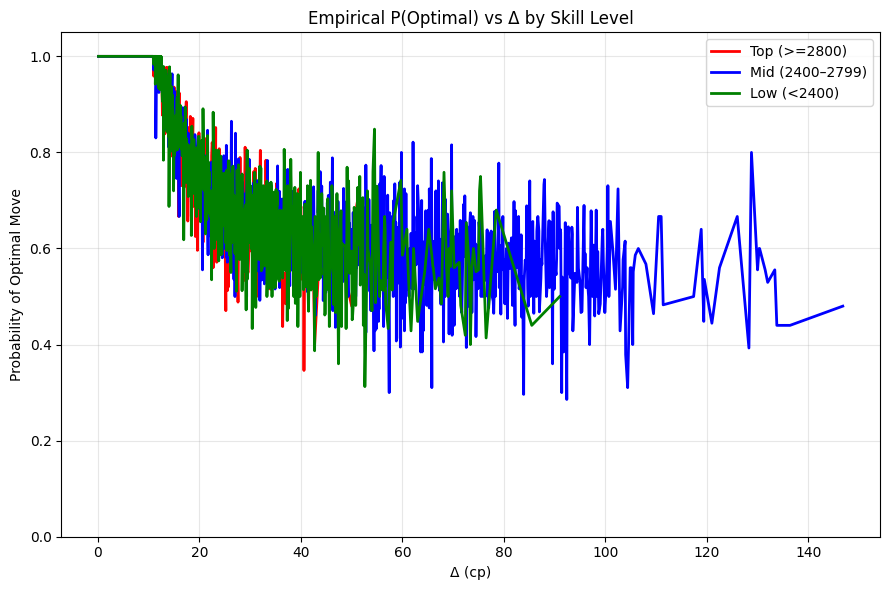

Top 组: A=0.522, 0.73A=0.381, Δ0≈40.6
Mid 组: A=0.526, 0.73A=0.384, Δ0≈92.4
Low 组: A=0.529, 0.73A=0.386, Δ0≈52.7


In [35]:
def empirical_curve(df, group_name, delta_max=1000, show_plot=True):
    group_df = df[(df['ELO_Group']==group_name) & (df['Is_Forced']==0)]
    
    # 只保留 Δ 在 1~delta_max 之间
    group_df = group_df[(group_df['Δ']>0) & (group_df['Δ']<=delta_max)]
    counts = group_df.groupby('Δ', observed=True)['Is_Optimal'].count()
    #只保留样本量大于100的点去画图
    valid_deltas = counts[counts >= 25].index
    group_df = group_df[group_df['Δ'].isin(valid_deltas)]

    # 按 Δ 统计概率
    prob_df = group_df.groupby('Δ', observed=True)['Is_Optimal'].mean().reset_index()
    prob_df.rename(columns={'Is_Optimal':'P_Optimal'}, inplace=True)
    
    if show_plot:
        plt.figure(figsize=(8,5))
        plt.plot(prob_df['Δ'], prob_df['P_Optimal'], 'b-', lw=2, label=f'{group_name} Empirical')
        plt.xlabel('Δ (cp)')
        plt.ylabel('Probability of Optimal Move')
        plt.title(f'Empirical Curve: {group_name}')
        plt.ylim(0,1.05)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
    
    return prob_df

def plot_all_groups(top_curve, mid_curve, low_curve):
    plt.figure(figsize=(9,6))

    plt.plot(top_curve['Δ'], top_curve['P_Optimal'],
             color='red', lw=2, label='Top (>=2800)')
    plt.plot(mid_curve['Δ'], mid_curve['P_Optimal'],
             color='blue', lw=2, label='Mid (2400–2799)')
    plt.plot(low_curve['Δ'], low_curve['P_Optimal'],
             color='green', lw=2, label='Low (<2400)')

    plt.xlabel('Δ (cp)')
    plt.ylabel('Probability of Optimal Move')
    plt.title('Empirical P(Optimal) vs Δ by Skill Level')
    plt.ylim(0,1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def get_empirical_delta0_left(prob_df, target_prob):
    """prob_df: 包含 ['Δ', 'P_Optimal'] 的 DataFrame（已按 Δ 排序）, target_prob: 目标概率（如 0.73 * A）"""
    x = prob_df['Δ'].values
    y = prob_df['P_Optimal'].values
    
    # 只保留 y 单调上升的区间（避免尾部抖动）
    mask = np.isfinite(y)
    x = x[mask]
    y = y[mask]
    
    # 如果 target 超出范围，直接返回 None
    if target_prob < y.min() or target_prob > y.max():
        return None
    
    # 插值反解
    delta0 = np.interp(target_prob, y, x)
    return delta0

def get_right_branch(prob_df):
    df = prob_df.sort_values('Δ').reset_index(drop=True)
    
    # 找到最小 P 的位置（下降 → 上升的转折点）
    idx_min = df['P_Optimal'].idxmin()
    
    # 只保留右半段
    return df.loc[idx_min:].reset_index(drop=True)

def get_empirical_delta0_right(prob_df, target_prob):
    right_df = get_right_branch(prob_df)
    
    x = right_df['Δ'].values
    y = right_df['P_Optimal'].values
    
    # 如果 target 不在范围内
    if target_prob < y.min() or target_prob > y.max():
        return None
    
    return np.interp(target_prob, y, x)

def get_empirical_ceiling(df, group_name): 
    # 筛选出该组的大 Delta 数据 (比如 200 到 1000 cp) 
    high_delta_data = df[ (df['ELO_Group'] == group_name) & (df['Δ'] > 200) & (df['Δ'] <= 1000) ] 
    # 直接算 Is_Optimal 的平均值
    A_empirical = high_delta_data['Is_Optimal'].mean() 
    return A_empirical 

# 对所有组循环
groups = df_moves['ELO_Group'].unique()
all_prob_curves = {}
for g in groups:
    all_prob_curves[g] = empirical_curve(df_moves, g, delta_max=500, show_plot=True)
top_curve = all_prob_curves['Top (>=2800)']
mid_curve = all_prob_curves['Mid (2400-2799)']
low_curve = all_prob_curves['Low (<2400)']
plot_all_groups(top_curve, mid_curve, low_curve)


A_top = get_empirical_ceiling(df_moves, 'Top (>=2800)') 
A_mid = get_empirical_ceiling(df_moves, 'Mid (2400-2799)') 
A_low = get_empirical_ceiling(df_moves, 'Low (<2400)') 
A_073_top = A_top*0.73 
A_073_mid = A_mid*0.73 
A_073_low = A_low*0.73 

top_delta0 = get_empirical_delta0_right(top_curve, A_073_top)
mid_delta0 = get_empirical_delta0_right(mid_curve, A_073_mid)
low_delta0 = get_empirical_delta0_right(low_curve, A_073_low)

print(f"Top 组: A={A_top:.3f}, 0.73A={A_073_top:.3f}, Δ0≈{top_delta0:.1f}")
print(f"Mid 组: A={A_mid:.3f}, 0.73A={A_073_mid:.3f}, Δ0≈{mid_delta0:.1f}")
print(f"Low 组: A={A_low:.3f}, 0.73A={A_073_low:.3f}, Δ0≈{low_delta0:.1f}")
